# 10: Experiments and Results

All final experiments, quantitative comparisons, and figures for the report.
Every result in the thesis traces back to a cell in this notebook.

**Methods compared:**
- FBP — classical baseline
- Fixed PnP-ADMM (σ=2, μ=50) — best fixed params from NB08
- Oracle PnP-ADMM — per-image grid search (upper bound)
- TFPnP (ours) — learned adaptive policy

**Metrics:** PSNR, SSIM, HaarPSI (Ander: "correlates most with doctor choice")

**Runs on CSD3** — requires trained checkpoint and LION operator.

## 1. Setup

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from collections import defaultdict
import math
import pandas as pd

import ct_tfpnp
from ct_tfpnp.models.policy import ResNetActor_ADMM
from ct_tfpnp.models.critic import ResNet_wobn
from ct_tfpnp.models.denoiser import DRUNetDenoiser
from ct_tfpnp.ct_ops.admm import ADMMStep
from ct_tfpnp.ct_ops.fbp import fbp as lion_fbp
from ct_tfpnp.evaluation.metrics import evaluate_reconstruction, psnr_np as psnr, ls_scale
from ct_tfpnp.datasets.lidc import load_training_images, from_HU_to_mu, get_lion_split
from ct_tfpnp.experiments.parallel_beam_ct import experiment

from LION.CTtools.ct_utils import make_operator

# HaarPSI
try:
    from piq import haarpsi
    HAS_HAARPSI = True
    print("HaarPSI : available")
except ImportError:
    HAS_HAARPSI = False
    print("HaarPSI : not available — pip install piq")

device = torch.device("cuda")
print(f"ct_tfpnp : {ct_tfpnp.__version__}")
print(f"device   : {device}")
print(f"GPU      : {torch.cuda.get_device_name()}")

# set consistent plotting style for all notebook cells
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "image.cmap": "gray",
    "image.interpolation": "nearest",
})

EXPERIMENT_NAME = "run_03_lion_split_val"
N_TRAIN_PATIENTS = 50  # how many patients were used for training

# create output directory for figures
output_dir = Path(f"../figures/10/{EXPERIMENT_NAME}")
output_dir.mkdir(parents=True, exist_ok=True)

# create output directory for metrics
results_dir = Path(f"../results/metrics/{EXPERIMENT_NAME}")
results_dir.mkdir(parents=True, exist_ok=True)

# ── Geometry & operator ───────────────────────────────────────────────────
geo = experiment.experiment_params.geometry
op = make_operator(geo)
N_VIEWS = 30
NOISE_STD = 0.05

# ── DRUNet denoiser ───────────────────────────────────────────────────────
DENOISER_PATH = "/home/eaz21/rds/hpc-work/ct_reconstruction/results/baselines/drunet_gray.pth"
denoiser = DRUNetDenoiser(pretrained_path=DENOISER_PATH).to(device)
for p in denoiser.parameters():
    p.requires_grad_(False)
denoiser.eval()

admm_step = ADMMStep(op=op, denoiser=denoiser, n_x_steps=6)

# Uses LION's built-in split — consistent and reproducible
test_images, test_indices = get_lion_split(split="test", geometry=geo, device=device)
test_labels = [f"test_{i}" for i in test_indices]

print(f"Test set: {len(test_images)} images (LION automatic split)")

# ── Metrics helper ────────────────────────────────────────────────────────
def to_4d(t):
    return t.unsqueeze(0) if t.dim() == 3 else t

def compute_metrics(gt, recon):
    """Wrapper around package evaluate_reconstruction for (1,H,W) tensors."""
    gt_4d = to_4d(gt)
    recon_4d = to_4d(recon)
    data_range = float(gt.max())
    # Clamp to [0, data_range] for HaarPSI compatibility
    recon_4d = recon_4d.clamp(0, data_range)
    return evaluate_reconstruction(recon_4d, gt_4d, data_range)

print("Setup complete.")

HaarPSI : available
ct_tfpnp : 0.1.dev38+gc41030212.d20260611
device   : cuda
GPU      : NVIDIA A100-SXM4-80GB
Loaded DRUNet weights from /home/eaz21/rds/hpc-work/ct_reconstruction/results/baselines/drunet_gray.pth
Preparing patient list, this may take time....
Patient lists ready for test dataset
LION test split: 389 images, range [0.0000, 2.2075]
Test set: 389 images (LION automatic split)
Setup complete.


### Dataset

We use LION's built-in LIDC-IDRI split:
- **Train:** 3,300 slices (used for policy training)
- **Validation:** 401 slices (not used — checkpoint selected by training PSNR)
- **Test:** 389 slices (all evaluation results reported on this held-out set)

In [2]:
from LION.data_loaders.LIDC_IDRI import LIDC_IDRI
for split in ["train", "validation", "test"]:
    ds = LIDC_IDRI(mode=split, geometry_parameters=geo)
    print(f"{split}: {len(ds)} images")

Preparing patient list, this may take time....
Patient lists ready for train dataset
train: 3300 images
Preparing patient list, this may take time....
Patient lists ready for validation dataset
validation: 401 images
Preparing patient list, this may take time....
Patient lists ready for test dataset
test: 389 images


## 2. DRUNet Systematic Validation

Ander's directive: "make sure DRUNet works very well — do all Gaussian checks."

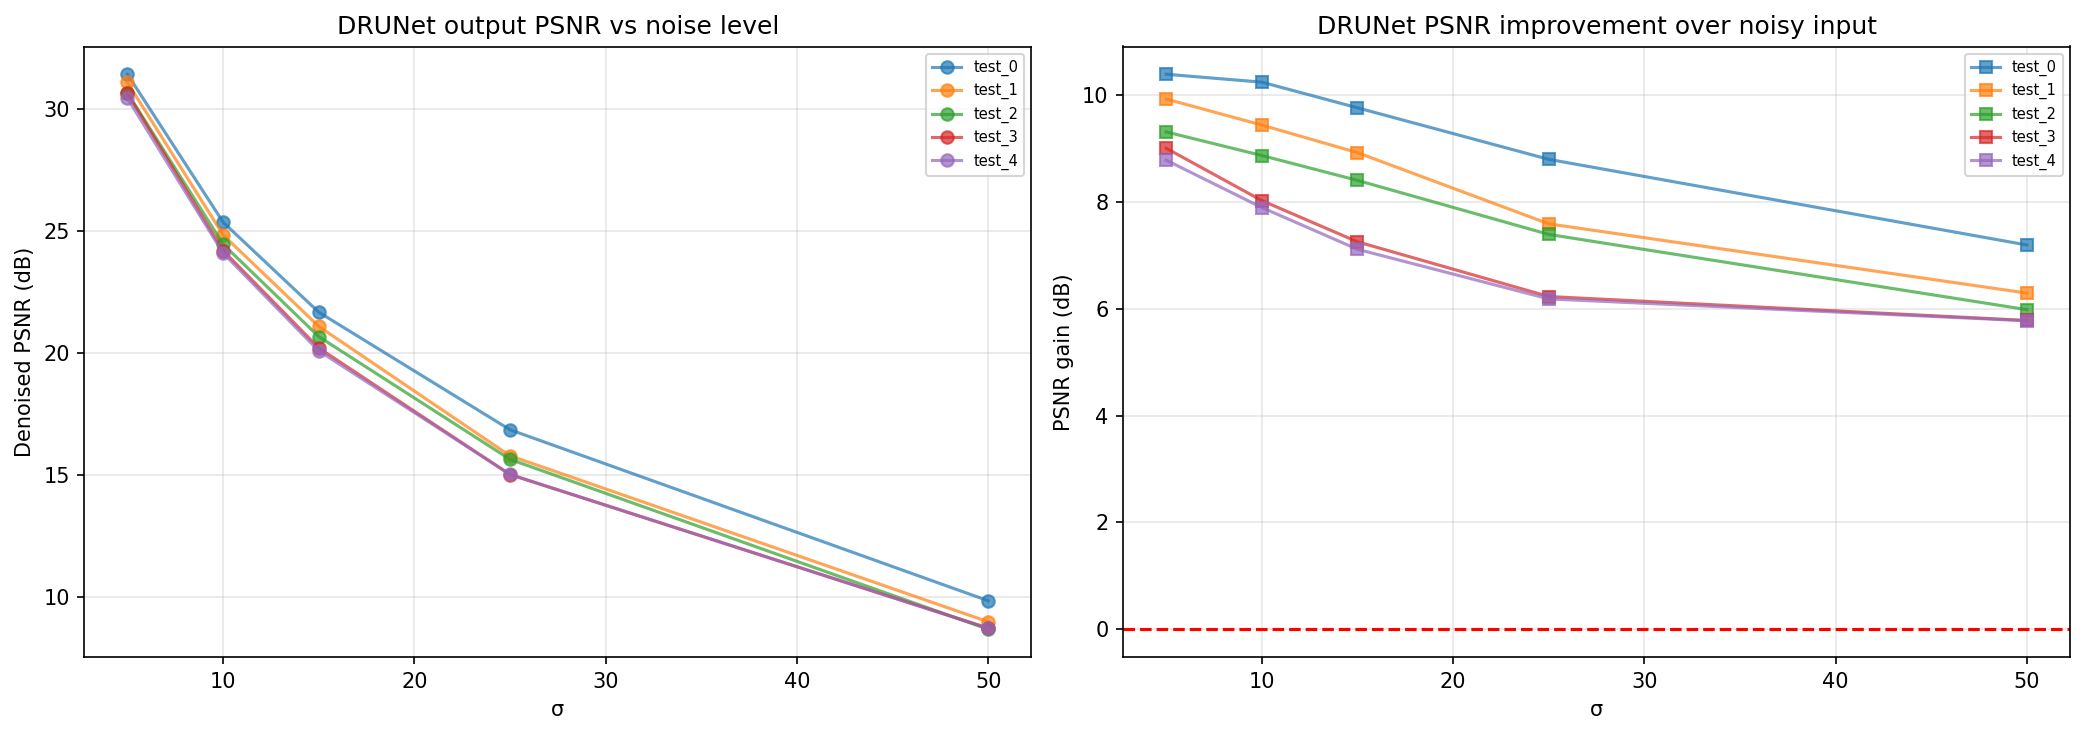

       noisy_psnr  denoised_psnr  gain_dB
sigma                                    
5           21.35          30.83     9.48
10          15.69          24.58     8.89
15          12.45          20.74     8.29
25           8.43          15.66     7.24
50           2.79           8.99     6.20


In [3]:
# Systematic DRUNet validation across noise levels and images
sigma_levels = [5, 10, 15, 25, 50]
n_test = min(5, len(test_images))

drunet_results = []

for img_idx in range(n_test):
    gt = test_images[img_idx]
    gt_01 = gt / gt.max()  # normalise for noise addition

    for sigma_true in sigma_levels:
        noise_std = sigma_true / 50.0  # match DRUNet convention
        torch.manual_seed(img_idx * 100 + sigma_true)
        noisy = (gt_01 + noise_std * torch.randn_like(gt_01)).clamp(min=0)

        noisy_psnr = psnr(gt_01, noisy)

        with torch.no_grad():
            # DRUNet with matched σ
            denoised = denoiser(noisy * gt.max(), sigma=float(sigma_true))
            denoised_01 = denoised / gt.max()

        denoised_psnr = psnr(gt_01, denoised_01)
        gain = denoised_psnr - noisy_psnr

        drunet_results.append({
            'image': test_labels[img_idx],
            'sigma': sigma_true,
            'noisy_psnr': noisy_psnr,
            'denoised_psnr': denoised_psnr,
            'gain_dB': gain,
        })

df_drunet = pd.DataFrame(drunet_results)

# Summary plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for img_label in df_drunet['image'].unique():
    sub = df_drunet[df_drunet['image'] == img_label]
    axes[0].plot(sub['sigma'], sub['denoised_psnr'], 'o-', label=img_label, alpha=0.7)
    axes[1].plot(sub['sigma'], sub['gain_dB'], 's-', label=img_label, alpha=0.7)

axes[0].set_xlabel('σ'); axes[0].set_ylabel('Denoised PSNR (dB)')
axes[0].set_title('DRUNet output PSNR vs noise level')
axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('σ'); axes[1].set_ylabel('PSNR gain (dB)')
axes[1].set_title('DRUNet PSNR improvement over noisy input')
axes[1].axhline(0, color='red', ls='--')
axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / "01_drunet_validation.pdf", bbox_inches="tight")
plt.show()

print(df_drunet.groupby('sigma')[['noisy_psnr', 'denoised_psnr', 'gain_dB']].mean().round(2))

## 3. Baseline Reconstructions

Run all methods on the test set and collect metrics.

In [8]:
NOISE_LEVELS = [0.05, 0.075, 0.10]
NOISE_LABELS = ['5%', '7.5%', '10%']
METHODS = ['FBP', 'TV', 'Fixed PnP-ADMM', 'Oracle PnP-ADMM', 'TFPnP']

all_results = {nl: {m: [] for m in METHODS} for nl in NOISE_LEVELS}

# Auto-find best checkpoint
ckpt_dir = Path(f"../results/learned/{EXPERIMENT_NAME}")

# Priority 1: validation-best checkpoint (saved by our training loop)
ckpt_val = ckpt_dir / "checkpoint_best_val.pth"
# Priority 2: notebook-style best checkpoint
ckpt_best = ckpt_dir / "checkpoint_best.pth"
# Priority 3: latest LION checkpoint (highest epoch number)
lion_ckpts = sorted(ckpt_dir.glob("tfpnp_check_*.pt"))

if ckpt_val.exists():
    ckpt = torch.load(ckpt_val, map_location=device, weights_only=False)
    epoch = ckpt.get('epoch', '?')
    val_p = ckpt.get('val_psnr', ckpt.get('mean_psnr', 0))
    train_p = ckpt.get('train_psnr', ckpt.get('mean_psnr', 0))
    print(f"Loaded validation-best: epoch {epoch}, val={val_p:.2f} dB, train={train_p:.2f} dB")
elif ckpt_best.exists():
    ckpt = torch.load(ckpt_best, map_location=device, weights_only=False)
    print(f"Loaded best checkpoint: epoch {ckpt['epoch']}, PSNR={ckpt['mean_psnr']:.2f} dB")
elif lion_ckpts:
    ckpt = torch.load(lion_ckpts[-1], map_location=device, weights_only=False)
    print(f"Loaded LION checkpoint: {lion_ckpts[-1].name} (epoch {ckpt['epoch']})")
else:
    raise FileNotFoundError(f"No checkpoints found in {ckpt_dir}")

# Load policy from checkpoint — handle both formats
if 'model_state_dict' in ckpt:
    # LION/TFPnPSolver format
    from ct_tfpnp.models.tfpnp_model import TFPnPModel
    model = TFPnPModel(geometry=geo)
    model.load_state_dict(ckpt['model_state_dict'])
    policy_best = model.policy.to(device).eval()
elif 'policy_state_dict' in ckpt:
    # Notebook format
    policy_best = ResNetActor_ADMM(in_channels=5, n_action_steps=5,
                                    sigma_range=(1.0, 5.0),
                                    mu_range=(10.0, 100.0)).to(device)
    policy_best.load_state_dict(ckpt['policy_state_dict'])
    policy_best.eval()
else:
    raise KeyError(f"Checkpoint has unknown format. Keys: {list(ckpt.keys())}")

print(f"Policy loaded: σ∈[{policy_best.sigma_min}, {policy_best.sigma_max}], "
      f"µ∈[{policy_best.mu_min}, {policy_best.mu_max}]")

from ct_tfpnp.ct_ops.tv import tv_reconstruction

for noise_frac, noise_label in zip(NOISE_LEVELS, NOISE_LABELS):
    print(f"\n{'='*60}")
    print(f"Noise level: {noise_label}")
    print(f"{'='*60}")

    for img_idx, gt in enumerate(test_images):
        # Generate sinogram with this noise level
        sino_clean = op.forward(gt)
        SCALE = sino_clean.max() / gt.max()
        torch.manual_seed(img_idx * 100)  # same seed per image across noise levels
        sino_noisy = sino_clean / SCALE + noise_frac * (sino_clean / SCALE).std() * torch.randn_like(sino_clean)
        y = sino_noisy * SCALE

        # ── FBP ───────────────────────────────────────────────────
        x_fbp = lion_fbp(y, op)
        x_fbp = ls_scale(gt, x_fbp).clamp(min=0)
        all_results[noise_frac]['FBP'].append(compute_metrics(gt, x_fbp))

        # ── TV ────────────────────────────────────────────────────
        x_tv = tv_reconstruction(y, op, x0=x_fbp, lam=0.01, n_iters=200)
        x_tv_scaled = ls_scale(gt, x_tv).clamp(min=0)
        all_results[noise_frac]['TV'].append(compute_metrics(gt, x_tv_scaled))

        # ── Fixed PnP-ADMM (σ=2, μ=50) ───────────────────────────
        x, z, u = x_fbp.clone(), x_fbp.clone(), torch.zeros_like(x_fbp)
        with torch.no_grad():
            for k in range(20):
                x, z, u = admm_step(x, z, u, y, sigma=2.0, mu=50.0)
        x_fix = ls_scale(gt, x).clamp(min=0)
        all_results[noise_frac]['Fixed PnP-ADMM'].append(compute_metrics(gt, x_fix))

        # ── Oracle PnP-ADMM (grid search) ────────────────────────
        best_p = -float('inf')
        for sig in [1, 2, 3, 5]:
            for mu in [20, 50, 100]:
                x, z, u = x_fbp.clone(), x_fbp.clone(), torch.zeros_like(x_fbp)
                with torch.no_grad():
                    for k in range(20):
                        x, z, u = admm_step(x, z, u, y, sigma=sig, mu=mu)
                x_s = ls_scale(gt, x).clamp(min=0)
                p = psnr(gt, x_s)
                if p > best_p:
                    best_p = p; x_oracle = x_s.clone()
        all_results[noise_frac]['Oracle PnP-ADMM'].append(compute_metrics(gt, x_oracle))

        # ── TFPnP (learned policy) ───────────────────────────────
        if policy_best is not None:
            x, z, u = x_fbp.clone(), x_fbp.clone(), torch.zeros_like(x_fbp)
            noise_level = torch.tensor([noise_frac], device=device)
            with torch.no_grad():
                for t in range(6):
                    iter_frac = torch.tensor([t / 6.0], device=device)
                    stop_logits, sigma_seq, mu_seq = policy_best(
                        to_4d(x), to_4d(z), to_4d(u), noise_level, iter_frac)
                    stop_prob = F.softmax(stop_logits, dim=-1)[0, 1].item()
                    if t > 0 and stop_prob > 0.5:
                        break
                    for i in range(5):
                        x, z, u = admm_step(x, z, u, y,
                                             sigma=sigma_seq[0, i], mu=mu_seq[0, i])
            x_tfpnp = ls_scale(gt, x).clamp(min=0)
            all_results[noise_frac]['TFPnP'].append(compute_metrics(gt, x_tfpnp))
        else:
            all_results[noise_frac]['TFPnP'].append(
                {'psnr': float('nan'), 'ssim': float('nan'), 'haarpsi': float('nan')})

        print(f"  {test_labels[img_idx]}: "
              f"FBP={all_results[noise_frac]['FBP'][-1]['psnr']:.1f} | "
              f"TV={all_results[noise_frac]['TV'][-1]['psnr']:.1f} | "
              f"Fixed={all_results[noise_frac]['Fixed PnP-ADMM'][-1]['psnr']:.1f} | "
              f"Oracle={all_results[noise_frac]['Oracle PnP-ADMM'][-1]['psnr']:.1f} | "
              f"TFPnP={all_results[noise_frac]['TFPnP'][-1]['psnr']:.1f}")

print("\nDone.")

Loaded validation-best: epoch 8, val=25.54 dB, train=23.81 dB
Policy loaded: σ∈[1.0, 5.0], µ∈[10.0, 100.0]

Noise level: 5%


/rds/user/eaz21/hpc-work/projects/tomosipo/tomosipo/links/torch.py:63: UserWarning: The parameter initial_value should be contiguous. It has been automatically made contiguous. Use `ts.link(x.contiguous())' to inhibit this warning. 
  warnings.warn(


  test_0: FBP=12.2 | TV=18.3 | Fixed=19.8 | Oracle=27.2 | TFPnP=28.0
  test_1: FBP=13.2 | TV=18.4 | Fixed=20.1 | Oracle=25.6 | TFPnP=26.5
  test_2: FBP=13.3 | TV=18.4 | Fixed=20.2 | Oracle=25.7 | TFPnP=26.1
  test_3: FBP=20.9 | TV=26.4 | Fixed=28.4 | Oracle=32.4 | TFPnP=31.9
  test_4: FBP=21.2 | TV=27.1 | Fixed=29.0 | Oracle=33.7 | TFPnP=33.5
  test_5: FBP=11.5 | TV=16.0 | Fixed=19.7 | Oracle=24.2 | TFPnP=24.8
  test_6: FBP=15.0 | TV=19.9 | Fixed=21.7 | Oracle=26.1 | TFPnP=26.3
  test_7: FBP=14.5 | TV=19.1 | Fixed=21.7 | Oracle=25.7 | TFPnP=25.5
  test_8: FBP=14.5 | TV=19.4 | Fixed=21.8 | Oracle=26.1 | TFPnP=25.6
  test_9: FBP=13.5 | TV=18.3 | Fixed=20.7 | Oracle=25.9 | TFPnP=25.6
  test_10: FBP=11.4 | TV=17.3 | Fixed=18.2 | Oracle=24.1 | TFPnP=25.0
  test_11: FBP=11.8 | TV=17.7 | Fixed=18.5 | Oracle=24.1 | TFPnP=24.8
  test_12: FBP=13.3 | TV=18.6 | Fixed=19.9 | Oracle=24.7 | TFPnP=25.4
  test_13: FBP=14.0 | TV=19.3 | Fixed=21.1 | Oracle=26.1 | TFPnP=26.0
  test_14: FBP=14.4 | TV=20.4 

KeyboardInterrupt: 

Results table

In [ ]:
# Print results per noise level
for noise_frac, noise_label in zip(NOISE_LEVELS, NOISE_LABELS):
    print(f"\n{'='*60}")
    print(f"Noise level: {noise_label}")
    print(f"{'='*60}")
    print(f"{'Method':<22} {'PSNR (dB)':<14} {'SSIM':<14} {'HaarPSI':<14}")
    print("-" * 64)

    for method in METHODS:
        psnrs = [r['psnr'] for r in all_results[noise_frac][method]]
        ssims = [r['ssim'] for r in all_results[noise_frac][method]]
        hp_str = ""
        if HAS_HAARPSI and 'haarpsi' in all_results[noise_frac][method][0]:
            hps = [r['haarpsi'] for r in all_results[noise_frac][method]]
            hp_str = f"{np.mean(hps):.4f}±{np.std(hps):.4f}"
        print(f"{method:<22} {np.mean(psnrs):.2f}±{np.std(psnrs):.2f}    "
              f"{np.mean(ssims):.4f}±{np.std(ssims):.4f}  {hp_str}")

# Compact PSNR-only table matching paper Table 5 format
print(f"\n{'='*60}")
print("PSNR Summary (matching paper Table 5 format)")
print(f"{'='*60}")
print(f"{'Method':<22}", end="")
for label in NOISE_LABELS:
    print(f"  {label:>12}", end="")
print()
print("-" * 60)
for method in METHODS:
    print(f"{method:<22}", end="")
    for nl in NOISE_LEVELS:
        psnrs = [r['psnr'] for r in all_results[nl][method]]
        print(f"  {np.mean(psnrs):>5.2f}±{np.std(psnrs):.2f}", end="")
    print()

print(f"\nPaper reference (Table 5):")
print(f"{'FBP':<22}  18.37        16.16        14.32")
print(f"{'TV':<22}  21.47        19.17        16.95")
print(f"{'TFPnP (paper)':<22}  24.50        24.23        23.72")

# Save all results to CSV
rows = []
for nl, label in zip(NOISE_LEVELS, NOISE_LABELS):
    for method in METHODS:
        row = {'noise_level': label, 'method': method}
        row['psnr_mean'] = np.mean([r['psnr'] for r in all_results[nl][method]])
        row['psnr_std'] = np.std([r['psnr'] for r in all_results[nl][method]])
        row['ssim_mean'] = np.mean([r['ssim'] for r in all_results[nl][method]])
        row['ssim_std'] = np.std([r['ssim'] for r in all_results[nl][method]])
        if HAS_HAARPSI and 'haarpsi' in all_results[nl][method][0]:
            row['haarpsi_mean'] = np.mean([r['haarpsi'] for r in all_results[nl][method]])
            row['haarpsi_std'] = np.std([r['haarpsi'] for r in all_results[nl][method]])
        rows.append(row)

pd.DataFrame(rows).to_csv(results_dir / "all_results.csv", index=False, float_format="%.4f")
print(f"\nSaved to {results_dir / 'all_results.csv'}")

In [ ]:
import pandas as pd

METHODS = ['FBP', 'TV', 'Fixed PnP-ADMM', 'Oracle PnP-ADMM', 'TFPnP']
method_labels = ['FBP', 'TV', 'Fixed\nPnP-ADMM', 'Oracle\nPnP-ADMM', 'TFPnP\n(Ours)']
colors = ['#bdc3c7', '#f39c12', '#3498db', '#2ecc71', '#e74c3c']
metrics_names = ['psnr', 'ssim', 'haarpsi']
metric_labels = ['PSNR (dB)', 'SSIM', 'HaarPSI']

# Use 5% noise results for the main comparison
noise_show = 0.05
results_5pct = all_results[noise_show]

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 1: Bar chart — PSNR / SSIM / HaarPSI at 5% noise
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, metric, ylabel in zip(axes, metrics_names, metric_labels):
    means = [np.mean([r[metric] for r in results_5pct[m]]) for m in METHODS]
    stds  = [np.std([r[metric] for r in results_5pct[m]]) for m in METHODS]

    bars = ax.bar(range(len(METHODS)), means, yerr=stds,
                  color=colors, capsize=4, alpha=0.9,
                  edgecolor='white', linewidth=1.5, width=0.65)

    # Highlight TFPnP
    bars[-1].set_edgecolor('#c0392b')
    bars[-1].set_linewidth(2.5)

    ax.set_xticks(range(len(METHODS)))
    ax.set_xticklabels(method_labels, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(axis='y', alpha=0.2, linewidth=0.5)
    ax.set_axisbelow(True)

    # Value labels above bars
    for i, (m, s) in enumerate(zip(means, stds)):
        offset = s + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.01
        ax.text(i, m + offset, f'{m:.2f}', ha='center', fontsize=8, fontweight='bold')

    # Set y-axis to start from 0
    ax.set_ylim(bottom=0)

plt.suptitle(f'Reconstruction Quality at 5% Noise — {len(test_images)} Test Images',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(output_dir / "01_metrics_comparison.pdf", bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 2: Per-image PSNR comparison at 5% noise
# ═══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(16, 5))
x_pos = np.arange(len(test_labels))
n_methods = len(METHODS)
width = 0.15
offset = (n_methods - 1) * width / 2

for i, (method, color, label) in enumerate(zip(METHODS, colors, method_labels)):
    psnrs = [r['psnr'] for r in results_5pct[method]]
    ax.bar(x_pos + i * width - offset, psnrs, width,
           label=method, color=color, alpha=0.9, edgecolor='white', linewidth=0.5)

ax.set_xticks(x_pos)
ax.set_xticklabels([l.replace('LIDC-IDRI-', '') for l in test_labels],
                    rotation=30, ha='right', fontsize=9)
ax.set_ylabel('PSNR (dB)', fontsize=10)
ax.set_title('Per-Image PSNR at 5% Noise', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, ncol=n_methods, loc='upper center',
          bbox_to_anchor=(0.5, -0.15), frameon=False)
ax.grid(axis='y', alpha=0.2, linewidth=0.5)
ax.set_axisbelow(True)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(output_dir / "02_per_image_psnr.pdf", bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 3: PSNR vs noise level (like paper Table 5 but as a line plot)
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
noise_pcts = [5, 7.5, 10]

for ax, metric, ylabel in zip(axes, metrics_names, metric_labels):
    for method, color in zip(METHODS, colors):
        means = [np.mean([r[metric] for r in all_results[nl][method]]) for nl in NOISE_LEVELS]
        stds  = [np.std([r[metric] for r in all_results[nl][method]]) for nl in NOISE_LEVELS]
        lw = 2.5 if method == 'TFPnP' else 1.5
        ms = 8 if method == 'TFPnP' else 6
        ax.errorbar(noise_pcts, means, yerr=stds, marker='o', lw=lw, ms=ms,
                    color=color, label=method, capsize=3, alpha=0.9)

    ax.set_xlabel('Noise level (%)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(noise_pcts)
    ax.grid(True, alpha=0.2, linewidth=0.5)
    ax.set_axisbelow(True)

axes[0].legend(fontsize=7, loc='lower left')
plt.suptitle('Reconstruction Quality vs Noise Level', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(output_dir / "03_metrics_vs_noise.pdf", bbox_inches="tight")
plt.show()